In [319]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [320]:
# Carregando o Dataset

df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


In [321]:
# 1 - Realize a primeira etapa de pré processamento dos dados.

In [322]:
# A) Verifique os tipos de dados.

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [324]:
# B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [325]:
df.isnull().sum() # numero de valores nulos por coluna

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [326]:
# Não existem dados faltantes em coluna alguma

In [327]:
# 2 - Realize a segunda etapa de pré processamento dos dados.

In [328]:
# A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

In [329]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [330]:
# B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

In [331]:
# Já podemos identificar a presenca de outliers na colunha 'Valor_Condominio' por apresentar valor min em 0, que esta muido distante das metricar seguintes.

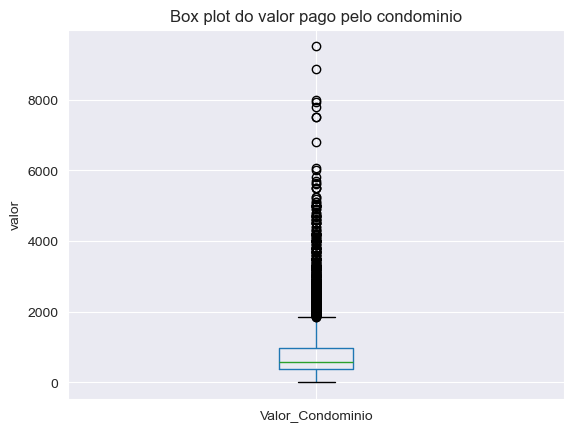

In [332]:
df.boxplot(column='Valor_Condominio')
plt.title('Box plot do valor pago pelo condominio')
plt.ylabel('valor')
plt.show()

In [333]:
df['Valor_Condominio'].mean() #media

811.5381091211995

In [334]:
df['Valor_Condominio'].median() #mediana

592.0

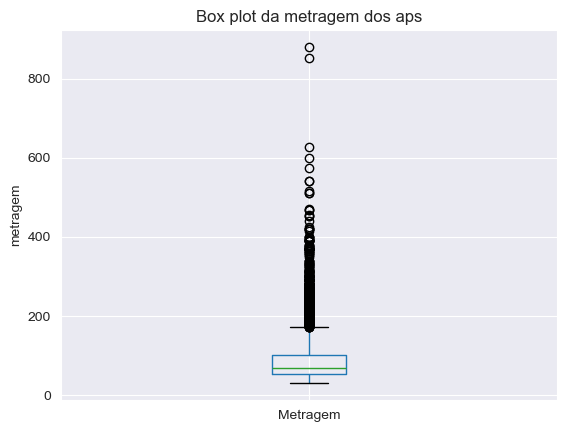

In [335]:
df.boxplot(column='Metragem')
plt.title('Box plot da metragem dos aps')
plt.ylabel('metragem')
plt.show()

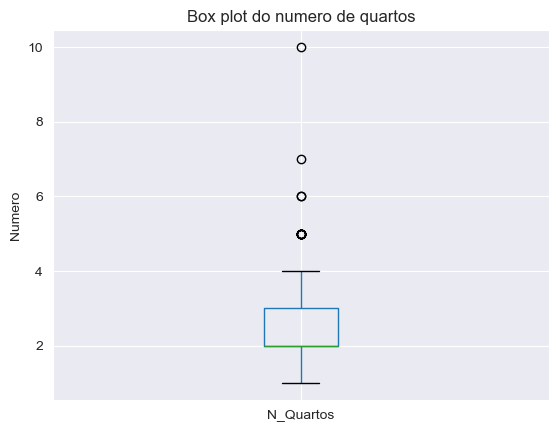

In [336]:
df.boxplot(column='N_Quartos')
plt.title('Box plot do numero de quartos')
plt.ylabel('Numero')
plt.show()

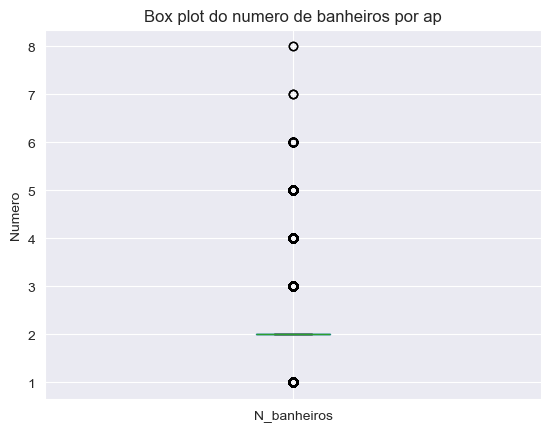

In [337]:
df.boxplot(column='N_banheiros')
plt.title('Box plot do numero de banheiros por ap')
plt.ylabel('Numero')
plt.show()

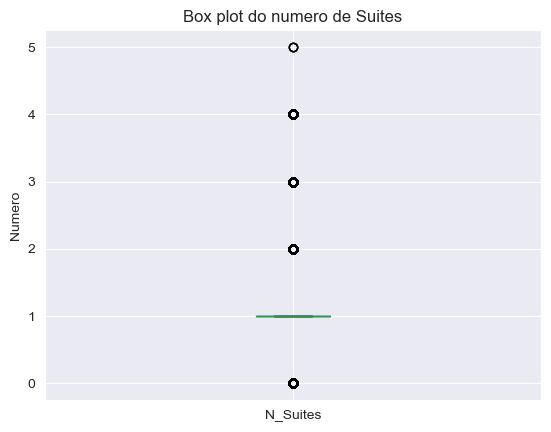

In [338]:
df.boxplot(column='N_Suites')
plt.title('Box plot do numero de Suites')
plt.ylabel('Numero')
plt.show()

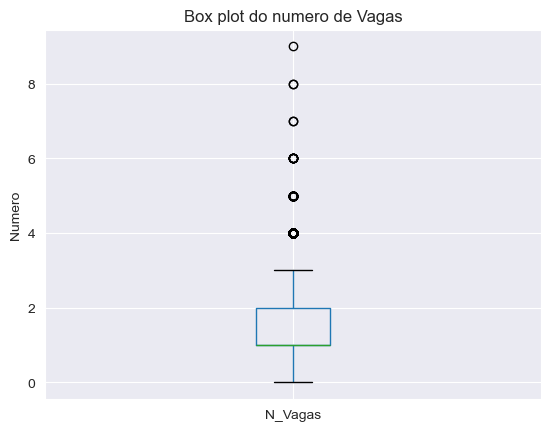

In [339]:
df.boxplot(column='N_Vagas')
plt.title('Box plot do numero de Vagas')
plt.ylabel('Numero')
plt.show()

In [340]:
# criamos um um novo dataset para adequar as colunas Valor_Condominio	Metragem, removendo os valores em outlier

# as outras colunas que apresentam outliers nao necessitam remocao de dados por nao apresentar forte disparidade, sendo assim, nao serao tratados como outliers 

In [341]:
# Vamos fazer uma copia do df 
df_novo = df.copy()

# Converte a coluna 'Valor_Condominio' para float
df_novo['Valor_Condominio'] = df_novo['Valor_Condominio'].astype(float)

# Criaremos os quartis do boxplot, para remover aqueles que estao nos quartis desejados
Q1 = df_novo['Valor_Condominio'].quantile(0.25)
Q3 = df_novo['Valor_Condominio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_sem_outliers = df_novo[(df_novo['Valor_Condominio'] >= limite_inferior) & (df_novo['Valor_Condominio'] <= limite_superior)]

# Calculando a media dos dados sem os valores menores ou iguais que 2000
media_sem_outliers = df_sem_outliers['Valor_Condominio'].mean()

# Substituindo os valores acima de 2000 pela media no dataframe

df_novo.loc[df_novo['Valor_Condominio'] >= 2000, 'Valor_Condominio'] = media_sem_outliers
media_sem_outliers

628.4299531509747

In [342]:
# Converte a coluna 'Metragem' para float
df_novo['Metragem'] = df_novo['Metragem'].astype(float)

# Criaremos os quartis do boxplot, para remover aqueles que estao nos quartis desejados
Q1 = df_novo['Metragem'].quantile(0.25)
Q3 = df_novo['Metragem'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_sem_outliers = df_novo[(df_novo['Metragem'] >= limite_inferior) & (df_novo['Metragem'] <= limite_superior)]

# Calculando a media dos dados sem os valores menores ou iguais que 190
media_sem_outliers = df_sem_outliers['Metragem'].mean()

# Substituindo os valores acima de 190 pela media no dataframe

df_novo.loc[df_novo['Metragem'] >= 190, 'Metragem'] = media_sem_outliers
media_sem_outliers 

73.32016473459427

In [343]:
# admito que fiquei com algumas duvidas nesta etapa. gostaria de saber se fiz a escolha certa, se fiz o metodo correto e se o resultado esta satisfatorio

In [344]:
# C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

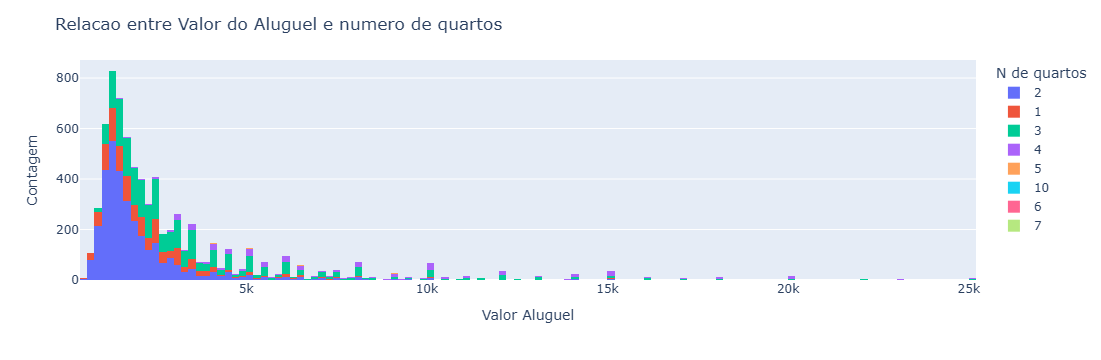

In [345]:
# Valor_Aluguel x N_Quartos

fig = px.histogram(df, x='Valor_Aluguel', color='N_Quartos', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Valor do Aluguel e numero de quartos',
		  xaxis_title='Valor Aluguel',
		  yaxis_title='Contagem',
		  legend_title='N de quartos')
fig.show()

In [346]:
# É possivel afirmar que o numero de quartos é uma variavel relevante pois a maioria dos aps mais baratos sao a maioria entre os aps de 1 a 3 quartos

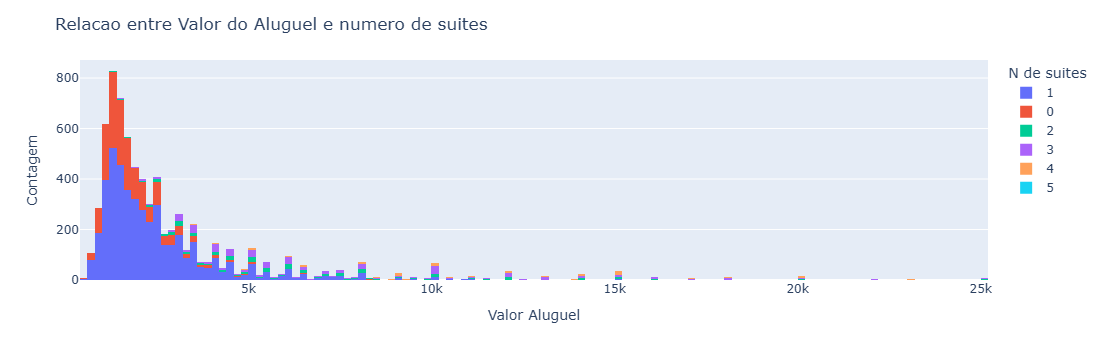

In [347]:
# Valor_Aluguel x N_Suites

fig = px.histogram(df, x='Valor_Aluguel', color='N_Suites', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Valor do Aluguel e numero de suites',
		  xaxis_title='Valor Aluguel',
		  yaxis_title='Contagem',
		  legend_title='N de suites')
fig.show()

In [348]:
# é possvel idenficiar que o numero de suites é relevante para o valor do aluguel pois os aps mais baratos sao a maioria dos que possuem 0 ou 1 suite

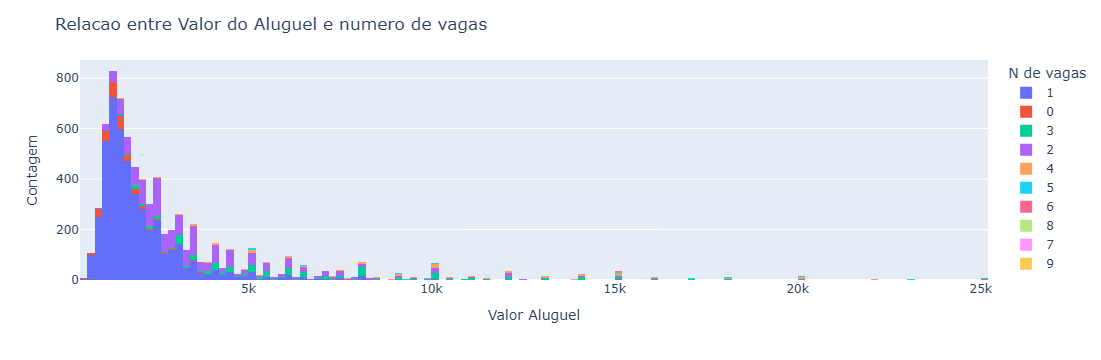

In [349]:
# Valor_Aluguel x N_Vagas

fig = px.histogram(df, x='Valor_Aluguel', color='N_Vagas', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre Valor do Aluguel e numero de vagas',
		  xaxis_title='Valor Aluguel',
		  yaxis_title='Contagem',
		  legend_title='N de vagas')
fig.show()

In [350]:
# podemos afirmar que o numero de vagas impacto no valor do aluguel pois a maioria dos aps com apenas 1 vaga encontrase em abundancia nos valores mais baixos

In [351]:
# 3 - Realize a terceira etapa de pré processamento dos dados.

In [352]:
# A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

In [353]:
# Matriz de correlacao

df_novo.select_dtypes(include=['number']).corr() # correlacao apenas entre as variaveis numericas

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
Valor_Aluguel,1.000000,0.342909,0.371636,0.413139,0.603715,0.614397,0.652858
Valor_Condominio,0.342909,1.000000,0.592843,0.360108,0.371037,0.332842,0.422586
Metragem,0.371636,0.592843,1.000000,0.581829,0.487360,0.439566,0.474839
N_Quartos,0.413139,0.360108,0.581829,1.000000,0.553807,0.540887,0.591224
N_banheiros,0.603715,0.371037,0.487360,0.553807,1.000000,0.920149,0.694983
N_Suites,0.614397,0.332842,0.439566,0.540887,0.920149,1.000000,0.712054
N_Vagas,0.652858,0.422586,0.474839,0.591224,0.694983,0.712054,1.000000


In [354]:
# Correlacao forte de 'Valor_Aluguel' com 'Metragem', 'N_banheiros', 'N_Suites' e 'N_Vagas'

In [355]:
# B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

# Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [356]:
X = df_novo.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
Y = df_novo['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

In [357]:
# Separar os dados em conjuntos de treino e teste

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# O parametro 'test_size' determina a proporcao dos dados que serao separados para teste (25% neste exemplo)
# o parametro 'random_state' é usado para garantir que a divisao seja reproduzivel

In [358]:
# 3 - Treine um modelo de regressão Linear simples

In [359]:
# A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, 
# a váriavel metragem.

In [360]:
X = X_train[['Metragem']]  # Variável independente (características)
Y = Y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [361]:
# Esta linha cria um objeto do tipo LinearRegression(), que será usado para representar nosso modelo de regressão linear

regressao_metragem = LinearRegression()

regressao_metragem.fit(X,Y)

# O modelo aprende a relacao entre as variaveis independentes (x) e a variavel dependente (y)
# Apos a execucao desta linha, o modelo estara pronto para fazer previsoes

LinearRegression()

In [362]:
# B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [363]:
# regressao_metragem.intercept_ é um atributo do objeto de regressao linear que representa o coeficiente linear da equacao
regressao_metragem.intercept_

506.3846989618105

In [364]:
# regressao_metragem.coef_ é um atributo do objeto de regressao linear que representa os coeficientes das variaveis independentes na equacao de regressao 
regressao_metragem.coef_

array([32.48490645])

In [365]:
regressao_metragem.score(X,Y)

0.14429976384670073

In [366]:
# Um coeficiente de 0.52 indica que aproximadamente 52% da variacao da variavel dependente é explicada pelas variaveis independentes incluidas no modelo de regressao.

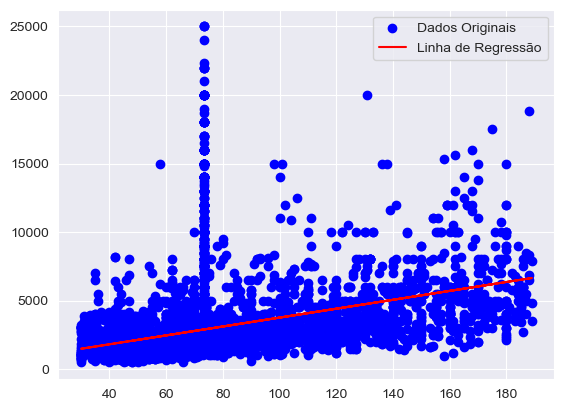

In [367]:
# Plotar os dados originais
plt.scatter(X, Y, color='blue', label='Dados Originais')

# Plotar a linha de regressao
plt.plot(X, regressao_metragem.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

In [368]:
# O ajuste mostra-se em correlacao forte com a linha de regressao, porem ainda com forte dispersao

In [369]:
previsoes = regressao_metragem.predict(X)
previsoes

array([6223.72823488, 2780.32815075, 2650.38852493, ..., 3592.4508121 ,
       2910.26777656, 2065.66020876])

In [370]:
# E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
#Para isso altere no código abaixo o nome do seu modelo de regressão:

In [371]:
X_test = X_test[['Metragem']]  # Variável independente (características)
Y_test = Y_test  # Variável dependente (rótulo)

In [372]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_metragem.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_metragem.score(X_test, Y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.12232953066139562


In [373]:
# 4 - Aplicação do modelo de regressão linear multipla

In [374]:
# A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes.
# Comece separando a base treino e teste, dessa vez com todas variáveis para X.

# Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [375]:
X = X_train[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]  # Variável independente (características)
Y = Y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

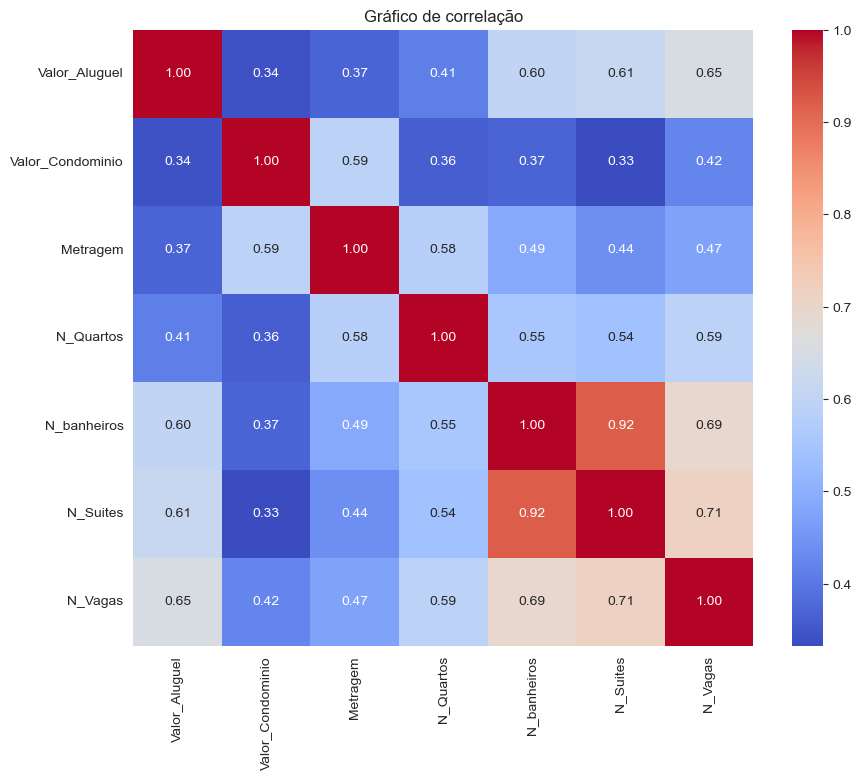

In [376]:
# Calculando a matriz de correlacao
correlacao = df_novo.corr()

# Gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Gráfico de correlação')
plt.show()

In [377]:
# Nenhuma variavel esta relacionada a 'Valor_Aluguel' de maneira satisfatoria. a mais bem colocada é 'N_Vagas'

In [378]:
#B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [379]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X,Y)

LinearRegression()

In [380]:
regressao_multipla.intercept_

-440.3000738912665

In [381]:
regressao_multipla.coef_

array([ 4.50882437e-01,  2.07106138e+00, -2.03052156e+02,  3.83003798e+02,
        7.10558529e+02,  1.31459532e+03])

In [382]:
# C) Traga o valor do R quadrado e avalie o valor encontrado.

In [383]:
regressao_multipla.score(X,Y)

0.47880364488069593

In [384]:
# o modelo de regressão explica 47% da variância da variável dependente.

In [385]:
# D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
# Dica: Você pode usar os códigos do exercício anterior.

In [419]:
X = X_test[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']] # Variável independente (características)
Y_test = df[['Valor_Aluguel']] 
Y = Y_test # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [420]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X,Y)

LinearRegression()

In [421]:
regressao_multipla.score(X,Y)

0.6076098775929859

In [ ]:
# E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. 
# Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

In [ ]:
# Neste caso, a regressao multipla entregou melhores resultados, provavelmente porquê o R² Utilizada quando você quer modelar a relação linear entre duas ou mais variáveis independentes e uma variável dependente.